# **Salmonid Mortality Data**
### Tidy Tuesday
*March 17, 2026*

### **Background**
The Norwegian Veterinary Institute has updated their annual *Fish Health Report*. This report centers around the health and welfare of farmed fish in Norway. Along with the Norwegian Food Safety Authority, these government agencies aim to lower fish mortality and to provide healthy fish for consumption. They are interested in how thei current work has progressed since January 2020, with some guiding questions:
* How does monthly mortality differ across the time period data is available for?
* Which region has lowest mortality?
* What other types of loses may be significant in addition to death of fish?

In [9]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Get data
monthly_losses_data = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-03-17/monthly_losses_data.csv')
monthly_mortality_data = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-03-17/monthly_mortality_data.csv')

### **Data Preview**
What information does the data tell?

In [4]:
monthly_losses_data

,species,date,geo_group,region,losses,dead,discarded,escaped,other
0,salmon,2020-01-01,area,1,31425,28126,3299,0,0
1,salmon,2020-01-01,area,2,324116,277888,46113,0,115
2,salmon,2020-01-01,area,3,844829,776983,63770,0,4076
3,salmon,2020-01-01,area,4,676852,623159,51823,0,1870
4,salmon,2020-01-01,area,5,109269,97627,11424,0,218
...,...,...,...,...,...,...,...,...,...
2803,rainbowtrout,2025-12-01,county,Møre og Romsdal,6597,6258,0,0,339
2804,rainbowtrout,2025-12-01,county,Trøndelag,292,283,0,0,9
2805,rainbowtrout,2025-12-01,county,Nordland,325,325,0,0,0
2806,rainbowtrout,2025-12-01,county,Troms,0,0,0,0,0


The above dataframe records the number of fish lost per day per region. It lists total losses, which is made up of dead fish, discarded fish (fish removed from the farm(s) due to disease/damage), escaped fish, and other losses.

In [5]:
monthly_mortality_data

,species,date,geo_group,region,median,q1,q3
0,rainbowtrout,2020-01-01,area,4,0.63,0.34,1.00
1,rainbowtrout,2020-02-01,area,4,0.60,0.41,1.17
2,rainbowtrout,2020-03-01,area,4,0.74,0.40,1.64
3,rainbowtrout,2020-04-01,area,4,0.51,0.19,1.59
4,rainbowtrout,2020-05-01,area,4,0.49,0.25,1.56
...,...,...,...,...,...,...,...
1783,salmon,2025-08-01,county,Finnmark,0.30,0.17,0.55
1784,salmon,2025-09-01,county,Finnmark,0.37,0.27,0.57
1785,salmon,2025-10-01,county,Finnmark,0.43,0.23,0.86
1786,salmon,2025-11-01,county,Finnmark,0.32,0.19,0.48


The above dataframe reports on the mortality rates per fish species in the regions.

### **Inspection**

In [14]:
print(monthly_losses_data.species.value_counts())
print()
print(monthly_mortality_data.species.value_counts())

species
salmon          1656
rainbowtrout    1152
Name: count, dtype: int64

species
salmon          1368
rainbowtrout     420
Name: count, dtype: int64


Both datasets have just the 2 species. I will now gather data specific to the two species.

In [108]:
# Subset by species
salmon = monthly_losses_data[monthly_losses_data['species']=='salmon'].reset_index().drop(['index'], axis=1)
rainbowtrout =  monthly_losses_data[monthly_losses_data['species']=='rainbowtrout'].reset_index().drop(['index'], axis=1)

In [105]:
# Get the total count of losses by category per species
def total_losses(df):
    # To record the final counts per month over time
    date = []
    losses = []
    dead = []
    discarded = []
    escaped = []
    other = []
    # Per each unique date
    for month in df.date.unique():
        # To record the sum of counts per each month
        mlosses = 0
        mdead = 0
        mdiscarded = 0
        mescaped = 0
        mother = 0
        for row in range(len(df)):
            # Check if date matches
            if df.loc[row]['date']==month:
                mlosses += df.loc[row]['losses']
                mdead += df.loc[row]['dead']
                mdiscarded += df.loc[row]['discarded']
                mescaped += df.loc[row]['escaped']
                mother += df.loc[row]['other']
        # Append the date and values
        date.append(month)
        losses.append(mlosses)
        dead.append(mdead)
        discarded.append(mdiscarded)
        escaped.append(mescaped)
        other.append(mother)
    # Return a new dataframe    
    loss_data = {
        'date':date,
        'losses': losses,
        'dead': dead,
        'discarded': discarded,
        'escaped': escaped,
        'other': other,
    }
    df2 = pd.DataFrame(loss_data)
    return df2

In [110]:
# Gather summed losses
salmon_losses = total_losses(salmon)
rainbowtrout_losses = total_losses(rainbowtrout)

In [115]:
# Above function can take a while to start...
# Export to csv for future analysis
salmon_losses.to_csv('salmon_losses.csv')
rainbowtrout_losses.to_csv('rainbowtrout_losses.csv')

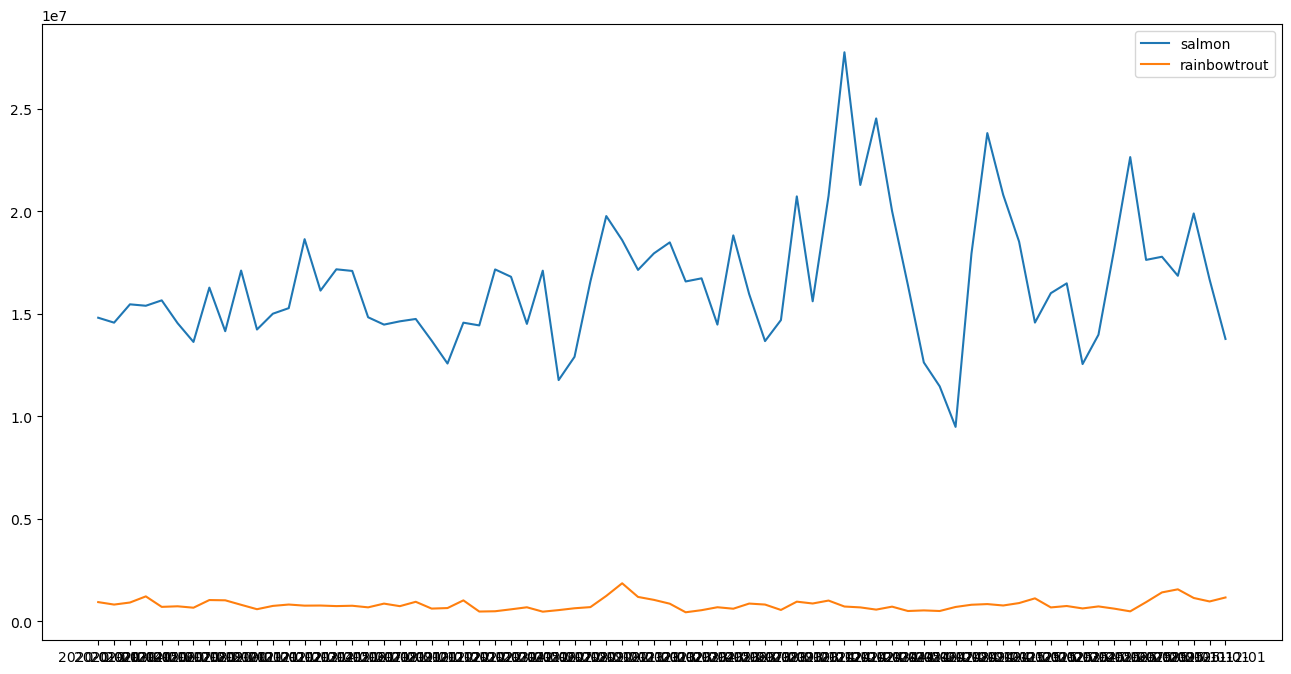

In [116]:
plt.figure(figsize=(16,8))
plt.plot(salmon_losses['date'], salmon_losses['losses'], label='salmon')
plt.plot(rainbowtrout_losses['date'], rainbowtrout_losses['losses'], label='rainbowtrout')
plt.legend()